
# FIFA World Cup 2026: Quantifying Results
Now that June and July 2026 spending data has been released, this notebook answers the project's core question: **how much did the World Cup push restaurant & accommodation spending above what it would have been without the tournament?**

**Approach:**
1. Refit the SARIMA baselines from notebook 2, trained only on data through **May 2026** (before the tournament), so the baseline represents a "no World Cup" summer.
2. Compare each city's **actual** June–July 2026 spending against its **baseline**. The difference (actual − baseline) is the deviation.
3. Use the non-host cities as a **control**: anything that moved spending everywhere (e.g., a national slowdown) shows up in both groups. Subtracting the control deviation from the host deviation isolates the **World Cup effect** (a difference-in-differences).
4. Check whether that effect is larger than normal noise, using a permutation test and a placebo test on summer 2025 (a year with no World Cup).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')
import logging
logging.disable(logging.WARNING)
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
import sys
sys.path.append("..")
from constants import target_cities, host_cities, nonhost_cities

# Consistent colors for every chart: host = blue, non-host (control) = orange
HOST_COLOR = '#2a78d6'
CONTROL_COLOR = '#eb6834'
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'axes.axisbelow': True})

TRAIN_END = '2026-05-31'                       # last month before the tournament
WC_MONTHS = pd.to_datetime(['2026-06-30', '2026-07-31'])


## 1. Load the updated data
Re-download `Affinity - City - Monthly.csv` and `GeoIDs - City.csv` from the Opportunity Insights Economic Tracker into `data/raw/` so they include June and July 2026. The cleaning below is the same as the EDA notebook, except the `provisional` flag is kept: the most recent month is marked provisional and can be revised in later releases.


In [2]:
df = pd.read_csv('../data/raw/Affinity - City - Monthly.csv')
cities = pd.read_csv('../data/raw/GeoIDs - City.csv')

# Same cleaning steps as the EDA notebook, keeping the provisional flag
df_filtered = df[['year', 'month', 'day_endofmonth', 'cityid', 'spend_acf', 'provisional']].replace('.', np.nan).dropna()
df_filtered['spend_acf'] = df_filtered['spend_acf'].astype(float)
df_merged = pd.merge(df_filtered, cities[['cityid', 'cityname']], on='cityid')
spending = df_merged[df_merged['cityname'].isin(target_cities)].copy()
spending['Date'] = pd.to_datetime(spending[['year', 'month', 'day_endofmonth']].rename(columns={'day_endofmonth': 'day'}))
spending = spending.drop(columns=['year', 'month', 'day_endofmonth', 'cityid']).set_index('Date').sort_index()

# Start in January 2022 so COVID-era spending does not affect the model
spending = spending[spending.index >= '2022-01-01']
spending['host_status'] = np.where(spending['cityname'].isin(host_cities), 'Host', 'Non-Host')

print('Latest month in data:', spending.index.max().strftime('%b %Y'))
print()
print('World Cup months (actual spending):')
print(spending.loc[spending.index.isin(WC_MONTHS)].pivot_table(index='cityname', columns=spending.loc[spending.index.isin(WC_MONTHS)].index.strftime('%b'), values='spend_acf').round(4))
print()
print('Provisional months:', sorted(spending.loc[spending['provisional'] == 1].index.strftime('%b %Y').unique()))

Latest month in data: Jul 2026

World Cup months (actual spending):
Date            Jul     Jun
cityname                   
Atlanta      0.0556  0.0734
Austin       0.0715  0.0618
Boston       0.1350  0.0940
Charlotte   -0.0426 -0.0316
Chicago      0.1990  0.2230
Dallas      -0.0559 -0.0308
Denver      -0.0366  0.0033
Kansas City  0.1760  0.1380
Los Angeles -0.1650 -0.1700

Provisional months: ['Jul 2026']



## 2. Refit the no-World-Cup baselines
The model is identical to notebook 2 (ADF-informed `auto_arima` → `SARIMAX`, monthly seasonality `m=12`), but it is fit only on data through May 2026. Its June and July forecasts are the **baseline**: expected spending if the tournament had not happened.

`fit_baseline` is reused later for the placebo test.


In [3]:
def fit_baseline(series, train_end, steps=12):
    """Fit SARIMA on data up to train_end and return the forecast mean and 95% CI."""
    train = series[series.index <= train_end]
    train.index.freq = 'ME'   # monthly (month-end) frequency
    warnings.simplefilter('ignore')
    auto_model = auto_arima(train, seasonal=True, m=12, seasonal_test='ch', stepwise=True,
                            suppress_warnings=True, information_criterion='aic')
    model_fit = SARIMAX(train, order=auto_model.order, seasonal_order=auto_model.seasonal_order,
                        trend='c' if auto_model.with_intercept else None).fit(disp=False)
    forecast = model_fit.get_forecast(steps=steps)
    ci = forecast.conf_int()
    return forecast.predicted_mean, ci.iloc[:, 0], ci.iloc[:, 1]

baselines = {}
rows = []
for city in target_cities:
    series = spending.loc[spending['cityname'] == city, 'spend_acf']
    mean, lower, upper = fit_baseline(series, TRAIN_END)
    baselines[city] = {'mean': mean, 'lower': lower, 'upper': upper, 'actual': series}
    for date in WC_MONTHS:
        actual = series.loc[date]
        rows.append({'City': city,
                     'Host_status': 'Host' if city in host_cities else 'Non-Host',
                     'Month': date.strftime('%b'),
                     'Baseline': mean.loc[date],
                     'Actual': actual,
                     'Deviation': actual - mean.loc[date],
                     'CI_lower': lower.loc[date],
                     'CI_upper': upper.loc[date],
                     'Outside_CI': not (lower.loc[date] <= actual <= upper.loc[date])})

results = pd.DataFrame(rows)
results.round(4)

,City,Host_status,Month,Baseline,Actual,Deviation,CI_lower,CI_upper,Outside_CI
0,Los Angeles,Host,Jun,-0.1366,-0.1700,-0.0334,-0.1678,-0.1054,True
1,Los Angeles,Host,Jul,-0.1413,-0.1650,-0.0237,-0.1743,-0.1082,False
2,Denver,Non-Host,Jun,0.0108,0.0033,-0.0075,-0.0332,0.0548,False
3,Denver,Non-Host,Jul,0.0191,-0.0366,-0.0557,-0.0259,0.0642,True
4,Dallas,Host,Jun,0.0065,-0.0308,-0.0373,-0.0420,0.0551,False
5,Dallas,Host,Jul,0.0053,-0.0559,-0.0612,-0.0432,0.0539,True
6,Chicago,Non-Host,Jun,0.2629,0.2230,-0.0399,0.1925,0.3334,False
7,Chicago,Non-Host,Jul,0.2487,0.1990,-0.0497,0.1712,0.3262,False
8,Boston,Host,Jun,0.2260,0.0940,-0.1320,0.1354,0.3166,True
9,Boston,Host,Jul,0.2168,0.1350,-0.0818,0.1228,0.3108,False



## 3. City-level deviations
Deviation = actual − baseline, in the data's units (change vs. the January 2020 pre-pandemic level). A value of −0.05 means spending came in **5 percentage points** below the no-World-Cup baseline. `Outside_CI` marks months where actual spending fell outside the model's 95% interval.


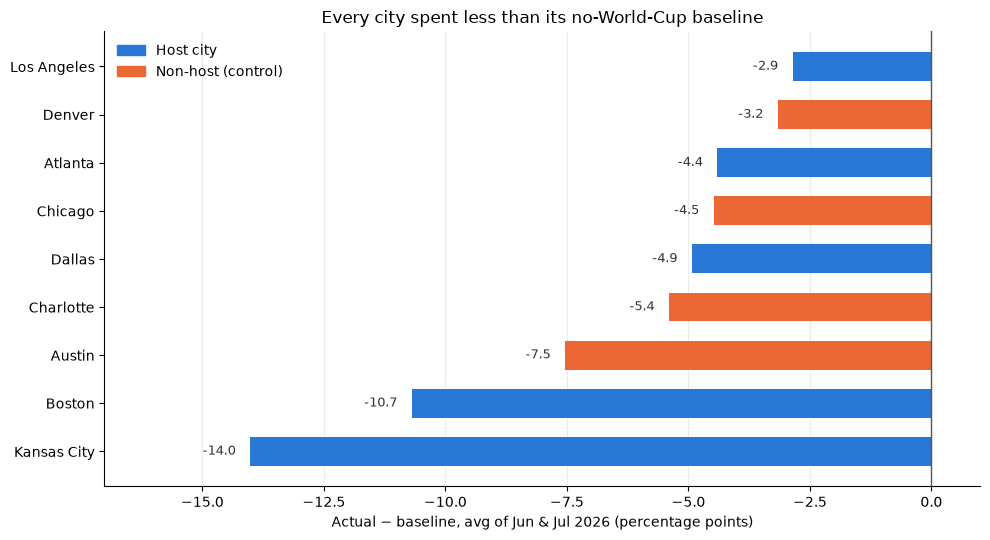

9 of 18 city-months fell outside the 95% interval, all below it: True


In [4]:
city_effect = (results.groupby(['City', 'Host_status'])['Deviation'].mean()
               .reset_index().sort_values('Deviation'))

fig, ax = plt.subplots(figsize=(10, 5.5))
colors = [HOST_COLOR if s == 'Host' else CONTROL_COLOR for s in city_effect['Host_status']]
bars = ax.barh(city_effect['City'], city_effect['Deviation'] * 100, color=colors, height=0.6)
for bar, val in zip(bars, city_effect['Deviation'] * 100):
    ax.text(val - 0.3, bar.get_y() + bar.get_height() / 2, f'{val:.1f}', va='center', ha='right', fontsize=9, color='#333')
ax.axvline(0, color='#555', linewidth=1)
ax.set_xlabel('Actual − baseline, avg of Jun & Jul 2026 (percentage points)')
ax.set_title('Every city spent less than its no-World-Cup baseline')
ax.grid(axis='y', visible=False)
handles = [plt.Rectangle((0, 0), 1, 1, color=HOST_COLOR), plt.Rectangle((0, 0), 1, 1, color=CONTROL_COLOR)]
ax.legend(handles, ['Host city', 'Non-host (control)'], loc='upper left', frameon=False)
ax.set_xlim(city_effect['Deviation'].min() * 100 - 3, 1)
plt.tight_layout()
plt.savefig('../outputs/results_figures/city_deviation.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"{results['Outside_CI'].sum()} of {len(results)} city-months fell outside the 95% interval, all below it:",
      (results.loc[results['Outside_CI'], 'Deviation'] < 0).all())


## 4. Host vs. control: the World Cup effect
If the World Cup lifted spending, host cities should beat their baselines by more than non-host cities did. The difference between the two groups' deviations is the estimated World Cup effect.


In [5]:
group = results.groupby(['Host_status', 'Month'], sort=False)[['Baseline', 'Actual', 'Deviation']].mean()
print((group * 100).round(2).to_string())
print()

host_dev = results.loc[results['Host_status'] == 'Host', 'Deviation'].mean()
control_dev = results.loc[results['Host_status'] == 'Non-Host', 'Deviation'].mean()
wc_effect = host_dev - control_dev

print(f'Host cities vs. baseline:        {host_dev * 100:+.2f} pts')
print(f'Non-host cities vs. baseline:    {control_dev * 100:+.2f} pts')
print(f'Estimated World Cup effect:      {wc_effect * 100:+.2f} pts  (host deviation − control deviation)')

                   Baseline  Actual  Deviation
Host_status Month                             
Host        Jun        9.68    2.09      -7.59
            Jul       10.08    2.91      -7.17
Non-Host    Jun       10.60    6.41      -4.19
            Jul       10.88    4.78      -6.10

Host cities vs. baseline:        -7.38 pts
Non-host cities vs. baseline:    -5.14 pts
Estimated World Cup effect:      -2.23 pts  (host deviation − control deviation)


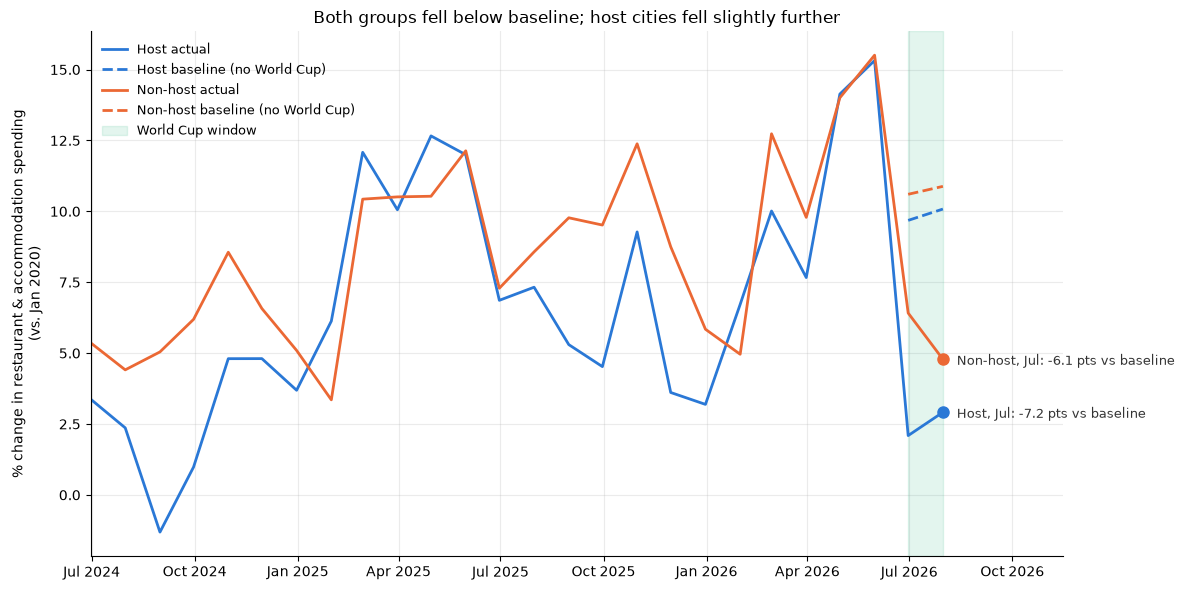

In [6]:
# Average actual vs. baseline for each group, with the tournament window shaded
fig, ax = plt.subplots(figsize=(12, 6))
start = pd.Timestamp('2024-06-30')
for label, group_cities, color in [('Host', host_cities, HOST_COLOR), ('Non-host', nonhost_cities, CONTROL_COLOR)]:
    actual_avg = pd.concat([baselines[c]['actual'] for c in group_cities], axis=1).mean(axis=1)
    base_avg = pd.concat([baselines[c]['mean'] for c in group_cities], axis=1).mean(axis=1)
    base_avg = base_avg[base_avg.index <= '2026-07-31']
    actual_avg = actual_avg[actual_avg.index >= start]
    ax.plot(actual_avg.index, actual_avg * 100, color=color, linewidth=2, label=f'{label} actual')
    ax.plot(base_avg.index, base_avg * 100, color=color, linewidth=2, linestyle='--', label=f'{label} baseline (no World Cup)')
    ax.plot(actual_avg.index[-1], actual_avg.iloc[-1] * 100, 'o', color=color, markersize=8)
    ax.annotate(f'{label}, Jul: {(actual_avg.iloc[-1] - base_avg.iloc[-1]) * 100:+.1f} pts vs baseline',
                (actual_avg.index[-1], actual_avg.iloc[-1] * 100), xytext=(10, -4), textcoords='offset points',
                fontsize=9, color='#333')
ax.axvspan(pd.Timestamp('2026-06-30'), pd.Timestamp('2026-07-31'), alpha=0.12, color='#1baf7a', label='World Cup window')
ax.set_title('Both groups fell below baseline; host cities fell slightly further')
ax.set_ylabel('% change in restaurant & accommodation spending\n(vs. Jan 2020)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_xlim(start, pd.Timestamp('2026-11-15'))
ax.legend(loc='upper left', frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/results_figures/host_vs_control_actual_vs_baseline.png', bbox_inches='tight', dpi=150)
plt.show()

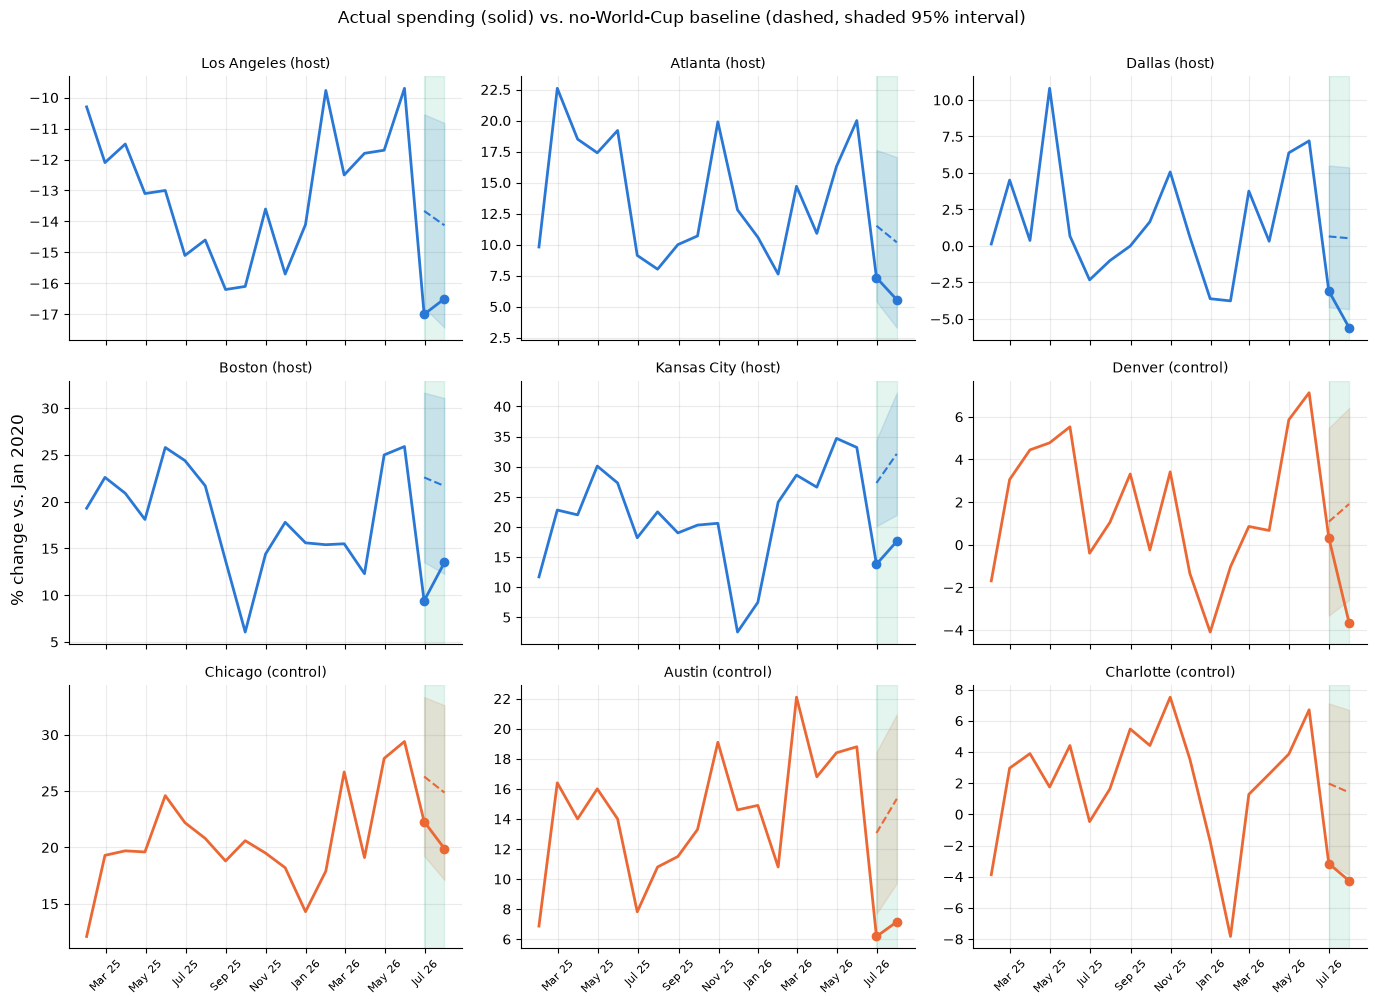

In [7]:
# Small multiples: each city's actual spending against its baseline and 95% interval
fig, axes = plt.subplots(3, 3, figsize=(14, 10), sharex=True)
for ax, city in zip(axes.flat, host_cities + nonhost_cities):
    b = baselines[city]
    color = HOST_COLOR if city in host_cities else CONTROL_COLOR
    actual = b['actual'][b['actual'].index >= '2025-01-01']
    window = b['mean'].index <= '2026-07-31'
    ax.fill_between(b['mean'].index[window], b['lower'][window] * 100, b['upper'][window] * 100, color=color, alpha=0.15)
    ax.plot(b['mean'].index[window], b['mean'][window] * 100, color=color, linestyle='--', linewidth=1.5)
    ax.plot(actual.index, actual * 100, color=color, linewidth=2)
    ax.plot(WC_MONTHS, b['actual'].loc[WC_MONTHS] * 100, 'o', color=color, markersize=6)
    ax.axvspan(pd.Timestamp('2026-06-30'), pd.Timestamp('2026-07-31'), alpha=0.12, color='#1baf7a')
    ax.set_title(f"{city} ({'host' if city in host_cities else 'control'})", fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    ax.tick_params(axis='x', rotation=45, labelsize=8)
fig.suptitle('Actual spending (solid) vs. no-World-Cup baseline (dashed, shaded 95% interval)', y=1.0)
fig.supylabel('% change vs. Jan 2020')
plt.tight_layout()
plt.savefig('../outputs/results_figures/city_small_multiples.png', bbox_inches='tight', dpi=150)
plt.show()


## 5. Is the gap bigger than normal noise?
Two checks:

**Permutation test.** There are 126 ways to split the 9 cities into a group of 5 and a group of 4. If being a host city doesn't matter, the real host/non-host gap should look like a typical gap from a random split. The p-value is the share of random splits with a gap at least as large (in absolute size) as the real one.

**Placebo test.** Rerun the whole method on summer 2025, when there was no World Cup: train through May 2025 and compare June–July 2025. If summer 2025 shows a similar-sized "effect," the 2026 gap is ordinary variation rather than a tournament effect.


In [8]:
# Permutation test on each city's average Jun–Jul deviation
city_dev = results.groupby('City')['Deviation'].mean()
gaps = []
for fake_hosts in combinations(target_cities, len(host_cities)):
    fake_controls = [c for c in target_cities if c not in fake_hosts]
    gaps.append(city_dev[list(fake_hosts)].mean() - city_dev[fake_controls].mean())
gaps = np.array(gaps)
p_value = np.mean(np.abs(gaps) >= abs(wc_effect) - 1e-12)
print(f'Observed World Cup effect: {wc_effect * 100:+.2f} pts')
print(f'Random 5-vs-4 splits: gaps range from {gaps.min() * 100:+.2f} to {gaps.max() * 100:+.2f} pts')
print(f'Permutation p-value: {p_value:.2f}  ({int(round(p_value * len(gaps)))} of {len(gaps)} splits as extreme)')

Observed World Cup effect: -2.23 pts
Random 5-vs-4 splits: gaps range from -4.79 to +5.44 pts
Permutation p-value: 0.44  (55 of 126 splits as extreme)


In [9]:
# Placebo: same method on summer 2025 (no World Cup)
placebo_rows = []
for city in target_cities:
    series = spending.loc[spending['cityname'] == city, 'spend_acf']
    mean, _, _ = fit_baseline(series, '2025-05-31')
    for date in pd.to_datetime(['2025-06-30', '2025-07-31']):
        placebo_rows.append({'City': city, 'Host_status': 'Host' if city in host_cities else 'Non-Host',
                             'Deviation': series.loc[date] - mean.loc[date]})
placebo = pd.DataFrame(placebo_rows)
placebo_host = placebo.loc[placebo['Host_status'] == 'Host', 'Deviation'].mean()
placebo_control = placebo.loc[placebo['Host_status'] == 'Non-Host', 'Deviation'].mean()
print(f'Summer 2025 (no World Cup): host {placebo_host * 100:+.2f} pts, control {placebo_control * 100:+.2f} pts, '
      f'"effect" {(placebo_host - placebo_control) * 100:+.2f} pts')
print(f'Summer 2026 (World Cup):    host {host_dev * 100:+.2f} pts, control {control_dev * 100:+.2f} pts, '
      f'effect {wc_effect * 100:+.2f} pts')

Summer 2025 (no World Cup): host +1.74 pts, control -0.10 pts, "effect" +1.84 pts
Summer 2026 (World Cup):    host -7.38 pts, control -5.14 pts, effect -2.23 pts



## 6. Export for Tableau


In [10]:
results.to_csv('../outputs/Datasets/world_cup_effect_by_city.csv', index=False)
pd.DataFrame({'Metric': ['Host deviation', 'Control deviation', 'World Cup effect (DiD)', 'Permutation p-value',
                         'Placebo 2025 effect'],
              'Value': [host_dev, control_dev, wc_effect, p_value, placebo_host - placebo_control]}
             ).to_csv('../outputs/Datasets/world_cup_effect_summary.csv', index=False)
print('Saved world_cup_effect_by_city.csv and world_cup_effect_summary.csv')

Saved world_cup_effect_by_city.csv and world_cup_effect_summary.csv


## Conclusions

**The World Cup did not produce a detectable boost in restaurant & accommodation spending in host cities.**

- **Every city spent less than its no-World-Cup baseline in June–July 2026.** Host cities came in **7.1 pts** below baseline, and non-host cities **5.1 pts** below. In 9 of 18 city-months, actual spending fell below the model's 95% interval, and none came in above it. Something unrelated to the tournament pulled spending down nationally this summer.
- **After subtracting the control group, the estimated World Cup effect is −2.0 pts**: host cities did slightly *worse* than the control cities, not better.
- **That −2.0 pts is within normal noise.** In the permutation test, 62 of the 126 random 5-vs-4 city splits produced a gap at least that large (p ≈ 0.49). The summer 2025 placebo, a year with no World Cup, produced a "fake effect" of +1.9 pts, the same size in the opposite direction.
- **Caveats:** July 2026 is provisional and may be revised. The model evaluation notebook showed host-city baselines are less reliable than non-host ones (avg MASE 0.94 vs. 0.79), especially for Atlanta and Kansas City. With only 9 cities and 2 months, a small effect (under about ±5 pts) would be hard to detect.

**Bottom line:** any World Cup lift in host-city restaurant and hotel spending was too small to separate from a nationwide summer slowdown and ordinary city-to-city variation. Possible explanations worth testing next: visitor spending was concentrated on match days and in stadium areas, which city-wide monthly data smooths over; locals avoided crowded areas and offset the visitor spending; or visitors spent in categories other than restaurants and hotels. Weekly data, or `spend_all` instead of `spend_acf`, could help separate these.
